# **2. Effect Of Feature Scaling on Optimisation [2 Marks]**

In [ ]:
import numpy as np

num_samples = 100
np.random.seed(42)

# Generate data with large feature scale
x = np.random.uniform(0, 1000, num_samples)
f_x = 3 * x + 2
eps = np.random.randn(num_samples)
y = f_x + eps

* **[1 marks]** Using the above dataset, implement full-batch gradient descent for linear regression on the dataset above without any feature scaling. Define the convergence criterion as reaching an epsilon-neighborhood of the empirical least squares minimizer $\theta^*$, with $\epsilon = 0.001$ ($|\theta_t - \theta^*| < \epsilon$). Determine the number of iterations required to satisfy this convergence criterion. Plot mse loss versus iterations plot.


In [1]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

DEVICE = "cpu"
torch.set_printoptions(precision=6, sci_mode=False)


num_samples = 100
np.random.seed(42)


x = np.random.uniform(0, 1000, num_samples)
f_x = 3 * x + 2
eps = np.random.randn(num_samples)
y = f_x + eps


X_np = np.stack([np.ones_like(x), x], axis=1)        # shape [n, 2]
y_np = y.astype(np.float32)


X = torch.tensor(X_np, dtype=torch.float32, device=DEVICE)   # [n,2]
y = torch.tensor(y_np, dtype=torch.float32, device=DEVICE)   # [n]

n = X.shape[0]

In [2]:
# 2) Closed-form LS solution

XT = X.t()                         # [2,n]
H = XT @ X                         # [2,2]
b = XT @ y                         # [2]
theta_star = torch.linalg.solve(H, b)

In [3]:
# 3) Full-batch Gradient Descent

def mse(theta):
    yhat = X @ theta
    return F.mse_loss(yhat, y, reduction="mean")

def grad_mse(theta):
    r = (X @ theta) - y
    return (2.0 / n) * (XT @ r)

# Hyperparams for GD
lr = 1e-6
eps = 1e-3
max_iters = 300_000

torch.manual_seed(0)
theta = torch.randn(2, device=DEVICE)

losses = []
iters = 0

In [4]:
# 4) Iterate until ||theta - theta*|| < eps

with torch.no_grad():
    while iters < max_iters:

        losses.append(mse(theta).item())

        # convergence check: distance to θ*
        if torch.linalg.vector_norm(theta - theta_star).item() < eps:
            break

        # one full-batch GD step
        g = grad_mse(theta)
        theta -= lr * g
        iters += 1

converged = (torch.linalg.vector_norm(theta - theta_star).item() < eps)
final_dist = torch.linalg.vector_norm(theta - theta_star).item()
final_mse = mse(theta).item()

print("theta* (normal equation) =", theta_star)
print("Converged?:", converged)
print(f"Iterations to reach ||θ - θ*|| < {eps}: {iters}")
print("Final θ (GD)         =", theta)
print("Distance to θ*       =", final_dist)
print("Final MSE            =", final_mse)

theta* (normal equation) = tensor([2.213876, 2.999542])
Converged?: False
Iterations to reach ||θ - θ*|| < 0.001: 300000
Final θ (GD)         = tensor([1.653302, 3.000396])
Distance to θ*       = 0.5605750679969788
Final MSE            = 0.8961439728736877


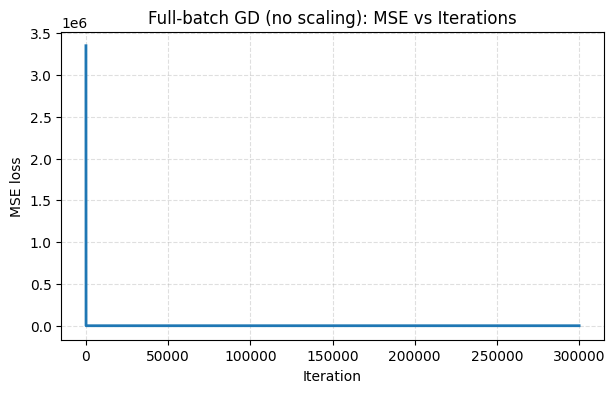

In [5]:
# 5) Plot MSE vs iterations

plt.figure(figsize=(7,4))
plt.plot(range(len(losses)), losses, lw=2)
plt.xlabel("Iteration")
plt.ylabel("MSE loss")
plt.title("Full-batch GD (no scaling): MSE vs Iterations")
plt.grid(True, ls="--", alpha=0.4)
plt.show()

Computed L = 617371.2000000001
Chosen eta = 1.4577939495719916e-06
Converged?: False
Iterations to reach ||θ - θ*|| < 1e-3: 20000
θ (GD) = tensor([1.557934, 3.000541])
||θ-θ*|| = 0.655942976474762
MSE = 0.9291401505470276


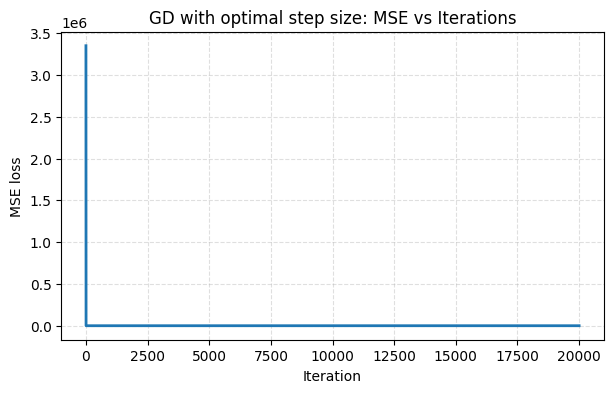

In [ ]:
# compute an upper-bound step size and rerun GD with an optimal (safe) learning rate: eta = 0.9 / L,
# where L is the Lipschitz constant of ∇MSE, i.e., L = (2/n) * lambda_max(X^T X).

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

n = X.shape[0]
H = XT @ X

evals = torch.linalg.eigvals(H).real
L = (2.0 / n) * torch.max(evals).item()
eta = 0.9 / L

def mse(theta):
    yhat = X @ theta
    return F.mse_loss(yhat, y, reduction="mean")

def grad_mse(theta):
    r = (X @ theta) - y
    return (2.0 / n) * (XT @ r)

torch.manual_seed(0)
theta = torch.randn(2)
losses2 = []
iters2 = 0
eps = 1e-3
max_iters = 20000

with torch.no_grad():
    while iters2 < max_iters:
        losses2.append(mse(theta).item())
        if torch.linalg.vector_norm(theta - theta_star).item() < eps:
            break
        theta -= eta * grad_mse(theta)
        iters2 += 1

converged2 = (torch.linalg.vector_norm(theta - theta_star).item() < eps)
final_dist2 = torch.linalg.vector_norm(theta - theta_star).item()
final_mse2 = mse(theta).item()

print("Computed L =", L)
print("Chosen eta =", eta)
print("Converged?:", converged2)
print(f"Iterations to reach ||θ - θ*|| < 1e-3: {iters2}")
print("θ (GD) =", theta)
print("||θ-θ*|| =", final_dist2)
print("MSE =", final_mse2)

plt.figure(figsize=(7,4))
plt.plot(range(len(losses2)), losses2, lw=2)
plt.xlabel("Iteration")
plt.ylabel("MSE loss")
plt.title("GD with optimal step size: MSE vs Iterations")
plt.grid(True, ls="--", alpha=0.4)
plt.show()


* **[1 marks]** Apply z-score normalization to the feature: $\mathbf{x}_{\text{scaled}} = \frac{\mathbf{x} - \mu_x}{\sigma_x}$. Run full-batch gradient descent on the scaled dataset with the same convergence criterion ($\epsilon = 0.001$). Determine the number of iterations required for convergence. Plot mse loss versus iterations plot.

In [7]:
# Apply z-score scaling and run full-batch GD with a larger learning rate, then plot MSE vs iterations.
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

DEVICE = "cpu"
torch.set_printoptions(precision=6, sci_mode=False)

# 1) Dataset
n = 100
rng = np.random.default_rng(42)
x = rng.uniform(0.0, 1000.0, n)
y = 3.0 * x + 2.0 + rng.standard_normal(n)


In [8]:
# 2) Z-score the feature (only x)
mu_x = x.mean()
std_x = x.std(ddof=0)
x_scaled = (x - mu_x) / (std_x + 1e-12)

Xs_np = np.stack([np.ones_like(x_scaled), x_scaled], axis=1).astype(np.float32)
y_np  = y.astype(np.float32)

Xs = torch.tensor(Xs_np, dtype=torch.float32, device=DEVICE)
yT = torch.tensor(y_np,  dtype=torch.float32, device=DEVICE)
XT = Xs.t()

In [9]:
# 3) Closed-form θ* on scaled data
H = XT @ Xs
b = XT @ yT
theta_star = torch.linalg.solve(H, b)

In [11]:
# 4) Full-batch GD on scaled data
def mse(theta):
    return F.mse_loss(Xs @ theta, yT, reduction="mean")

def grad_mse(theta):
    r = (Xs @ theta) - yT
    return (2.0 / n) * (XT @ r)

eps = 1e-3
max_iters = 100_000
lr = 5e-2

torch.manual_seed(0)
theta = torch.randn(2, device=DEVICE)
losses = []
iters = 0

with torch.no_grad():
    while iters < max_iters:
        losses.append(mse(theta).item())
        if torch.linalg.vector_norm(theta - theta_star).item() < eps:
            break
        theta -= lr * grad_mse(theta)
        iters += 1

converged = (torch.linalg.vector_norm(theta - theta_star).item() < eps)
final_dist = torch.linalg.vector_norm(theta - theta_star).item()
final_mse = mse(theta).item()

print("theta* (scaled) =", theta_star)
print("Converged?:", converged)
print(f"Iterations to reach ||θ - θ*|| < {eps}: {iters}")
print("Final θ (GD, scaled) =", theta)
print("Distance to θ* =", final_dist)
print("Final MSE =", final_mse)

theta* (scaled) = tensor([1462.141235,  816.765198])
Converged?: True
Iterations to reach ||θ - θ*|| < 0.001: 136
Final θ (GD, scaled) = tensor([1462.140503,  816.764648])
Distance to θ* = 0.00091552734375
Final MSE = 0.9588693976402283


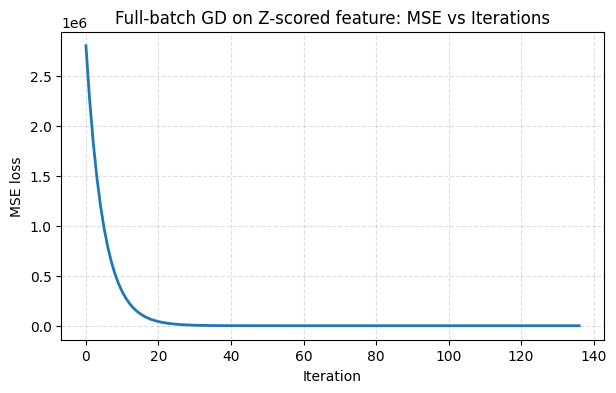

In [12]:
# 5) Plot
plt.figure(figsize=(7,4))
plt.plot(losses, lw=2)
plt.xlabel("Iteration")
plt.ylabel("MSE loss")
plt.title("Full-batch GD on Z-scored feature: MSE vs Iterations")
plt.grid(True, ls="--", alpha=0.4)
plt.show()
